# Tichy's Einblick
Load Tichy's Einblick CSV files and create a DataFrame named `df`.

In [1]:
from pathlib import Path
import re
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Tichy's Einblick"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()


def clean_tichy_text(text):
    if pd.isna(text):
        return text
    cleaned = str(text)
    cleaned = re.sub(
        r"ich\s+bin\s+damit\s+einverstanden,\s+dass\s+mir\s+inhalte\s+von\s+soundcloud\s+angezeigt\s+werden\.?",
        " ",
        cleaned,
        flags=re.IGNORECASE,
    )
    cleaned = re.sub(
        r"\b(?:abonnieren|itunes|amazon|spotify|inhalte|soundcloud|angezeigt)\b",
        " ",
        cleaned,
        flags=re.IGNORECASE,
    )
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned

source_col = next((c for c in df.columns if c.lower() in {"source", "outlet", "quelle"}), None)
if source_col is None:
    source_col = next((c for c in df.columns if any(k in c.lower() for k in ("source", "outlet", "quelle"))), None)
if source_col is not None:
    source_norm = (
        df[source_col]
        .astype("string")
        .str.lower()
        .str.replace("'", "", regex=False)
        .str.replace("’", "", regex=False)
        .str.strip()
    )
    tichy_mask = source_norm.eq("tichys einblick")
else:
    tichy_mask = pd.Series(True, index=df.index)

if "article_text" in df.columns:
    df.loc[tichy_mask, "article_text"] = df.loc[tichy_mask, "article_text"].apply(clean_tichy_text)

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")


Loaded 3126 rows from 195 file(s) in /Users/gretawette/Documents/Thesis/data/raw/Alternative Medien/Tichy's Einblick


In [2]:
df_clean = df.rename(
    columns={
        "title": "Title",
        "date": "Date",
        "url": "URL",
        "author": "Author",
        "article_text": "Text",
    }
)[["Title", "Date", "URL", "Author", "Text", "source"]].copy()

df_clean.head()

,Title,Date,URL,Author,Text,source
0,Wegen Geschäften mit Russland: Trump droht Ind...,2025-08-01,https://www.tichyseinblick.de/kolumnen/aus-all...,Seyed Alireza Mousavi,Im Bemühen um ein Friedensabkommen mit der Ukr...,Tichy's Einblick
1,Wie robust ist der verfassungsrechtliche Schut...,2025-08-01,https://www.tichyseinblick.de/feuilleton/buech...,Roland Tichy,"Nein, das Bargeld wird nicht abgeschafft. Dies...",Tichy's Einblick
2,Bis zur Selbstaufgabe: Wie Merz die SPD-Linken...,2025-08-01,https://www.tichyseinblick.de/meinungen/israel...,Mario Thurnes,Die Rolle von Malu Dreyer in der SPD wurde 201...,Tichy's Einblick
3,Bayern führt Wassercent ein,2025-08-01,https://www.tichyseinblick.de/meinungen/bayern...,Thomas Kolbe,Ab dem 1. Juli 2026 bittet der Freistaat Bayer...,Tichy's Einblick
4,Klima-Terroristen: Linke sind nicht nett,2025-08-01,https://www.tichyseinblick.de/meinungen/linke-...,Anna Diouf,In NRW ist nach dem Anschlag auf einen Kabeltu...,Tichy's Einblick


Date filter

In [3]:
# filter timeframe Aug 2025 through Jan 2026 (inclusive) and keep as df_clean
start, end = "2025-08-01", "2026-01-31"

dates = pd.to_datetime(df_clean["Date"], errors="coerce")
mask = (dates >= pd.Timestamp(start)) & (dates <= pd.Timestamp(end))

df_clean = df_clean.loc[mask].copy()
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

print(f"Rows in selected period: {len(df_clean)}")
df_clean.sort_values("Date").head()

Rows in selected period: 2946


,Title,Date,URL,Author,Text,source
0,Wegen Geschäften mit Russland: Trump droht Ind...,2025-08-01,https://www.tichyseinblick.de/kolumnen/aus-all...,Seyed Alireza Mousavi,Im Bemühen um ein Friedensabkommen mit der Ukr...,Tichy's Einblick
14,Freispruch für Ballweg: Justizskandal in Stutt...,2025-08-01,https://www.tichyseinblick.de/podcast/te-wecke...,Holger Douglas,"Ich bin damit einverstanden, dass mir Inhalte ...",Tichy's Einblick
13,Mit Merz-Klingbeil nach Vorarbeit Merkel-Schol...,2025-08-01,https://www.tichyseinblick.de/daili-es-sential...,Fritz Goergen,Steuererhöhungen schließt SPD-Klingbeil nicht ...,Tichy's Einblick
12,Arbeitsmarkt im Sinkflug: 171.000 Arbeitslose ...,2025-08-01,https://www.tichyseinblick.de/meinungen/arbeit...,Thomas Punzmann,"Die Bundesagentur für Arbeit meldet, dass im J...",Tichy's Einblick
11,Bekennerschreiben: Antifa feiert Anschlag auf ...,2025-08-01,https://www.tichyseinblick.de/daili-es-sential...,Richard Schmitt,"„Die Zeit, an einer Versöhnung der Seiten zu a...",Tichy's Einblick


In [4]:
df_clean['Date'].min(), df_clean['Date'].max()


(Timestamp('2025-08-01 00:00:00'), Timestamp('2026-01-31 00:00:00'))

In [5]:
# Missing values overview for df_cleaned only
missing_count = df_clean.isna().sum()
missing_pct = (missing_count / len(df_clean) * 100).round(2) if len(df_clean) else missing_count.astype(float)

missing_summary = (
    pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
    .sort_values("missing_count", ascending=False)
)

print(f"df_clean — total rows: {len(df_clean):,}")
print(f"Total missing cells: {int(missing_count.sum()):,}")
display(missing_summary[missing_summary["missing_count"] > 0])


df_clean — total rows: 2,946
Total missing cells: 0


,missing_count,missing_pct


In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2946 entries, 0 to 2945
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Title   2946 non-null   object        
 1   Date    2946 non-null   datetime64[ns]
 2   URL     2946 non-null   object        
 3   Author  2946 non-null   object        
 4   Text    2946 non-null   object        
 5   source  2946 non-null   object        
dtypes: datetime64[ns](1), object(5)
memory usage: 161.1+ KB


In [7]:
# Check duplicates in df_cleaned for Title, Text, and URL
dup_title_mask = df_clean["Title"].duplicated(keep=False)
dup_text_mask = df_clean["Text"].duplicated(keep=False)
dup_url_mask = df_clean["URL"].duplicated(keep=False)

duplicate_summary = pd.DataFrame(
    {
        "column": ["Title", "Text", "URL"],
        "duplicate_rows": [
            int(dup_title_mask.sum()),
            int(dup_text_mask.sum()),
            int(dup_url_mask.sum()),
        ],
        "distinct_duplicated_values": [
            int(df_clean.loc[dup_title_mask, "Title"].nunique()),
            int(df_clean.loc[dup_text_mask, "Text"].nunique()),
            int(df_clean.loc[dup_url_mask, "URL"].nunique()),
        ],
    }
)

# Rows where at least one of the three fields is duplicated
any_dup_mask = dup_title_mask | dup_text_mask | dup_url_mask
duplicate_rows = df_clean.loc[any_dup_mask].copy()

print(f"Rows with duplicate Title: {dup_title_mask.sum():,}")
print(f"Rows with duplicate Text:  {dup_text_mask.sum():,}")
print(f"Rows with duplicate URL:   {dup_url_mask.sum():,}")
print(f"Rows with duplicate in Title/Text/URL (either): {any_dup_mask.sum():,}")

display(duplicate_summary)
display(duplicate_rows.head(20))

Rows with duplicate Title: 0
Rows with duplicate Text:  0
Rows with duplicate URL:   0
Rows with duplicate in Title/Text/URL (either): 0


,column,duplicate_rows,distinct_duplicated_values
0,Title,0,0
1,Text,0,0
2,URL,0,0


,Title,Date,URL,Author,Text,source


Recurring issue-sale / PDF-promo posts and a broader TE-Wecker roundup / podcast-format cluster surfaced in the exploratory BERTopic run. The inspection below documents those documents before they are excluded from the final modeling corpus.


In [ ]:
# Inspect and remove recurring non-editorial promo/format posts that drove the earlier noise topics.
tichys_issue_sale_mask = (
    df_clean["Title"].fillna("").str.contains(r"^Tichys Einblick \d{2}-\d{4}:", regex=True)
    | df_clean["URL"].fillna("").str.contains(r"/daili-es-sentials/tichys-einblick-\d{2}-\d{4}", regex=True)
    | df_clean["Text"].fillna("").str.contains(
        r"im Handel oder direkt als PDF erhältlich|direkt als PDF erhältlich",
        case=False,
        regex=True,
    )
)

tichys_te_wecker_format_mask = (
    df_clean["Title"].fillna("").str.contains(r"TE-Wecker am", case=False, regex=True)
    | df_clean["URL"].fillna("").str.contains(r"/podcast/te-wecker-am-", case=False, regex=True)
)

tichys_issue_sale_docs = df_clean.loc[tichys_issue_sale_mask, ["Date", "Title", "URL", "Text"]].copy()
tichys_issue_sale_docs["removal_reason"] = "issue_sale_pdf_promo"

tichys_te_wecker_format_docs = df_clean.loc[tichys_te_wecker_format_mask, ["Date", "Title", "URL", "Text"]].copy()
tichys_te_wecker_format_docs["removal_reason"] = "te_wecker_roundup_format"

tichys_removed_non_editorial = pd.concat(
    [tichys_issue_sale_docs, tichys_te_wecker_format_docs],
    ignore_index=True,
).drop_duplicates(subset=["Date", "Title", "URL"])
tichys_removed_non_editorial["TextExcerpt"] = (
    tichys_removed_non_editorial["Text"].fillna("").str.slice(0, 400)
)

tichys_removal_summary = (
    tichys_removed_non_editorial["removal_reason"]
    .value_counts()
    .rename_axis("removal_reason")
    .reset_index(name="removed_documents")
)

print(f"Non-editorial Tichys rows identified for exclusion: {len(tichys_removed_non_editorial):,}")
display(tichys_removal_summary)
display(tichys_removed_non_editorial[["Date", "Title", "URL", "TextExcerpt", "removal_reason"]].head(20))

df_clean = df_clean.loc[~(tichys_issue_sale_mask | tichys_te_wecker_format_mask)].copy()
print(f"Rows after removing non-editorial promo/format posts: {len(df_clean):,}")


In [16]:
tichys_clean = df_clean.copy()
tichys_clean['source'] = 'Tichys_Einblick'
tichys_clean = tichys_clean[['Date', 'Title', 'Text', 'source']].copy()
tichys_clean.to_csv("tichys_clean.csv", index=False, encoding="utf-8")

## BERTopic


Run BERTopic on cleaned full-text articles with `hdbscan_min_cluster_size=10`.


In [8]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "1a_BERTopic").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 1a_BERTopic")

project_root = resolve_project_root()
module_root = project_root / "1a_BERTopic"

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))


In [9]:
from bertopic_pipeline import run_bertopic_pipeline

In [10]:
from bertopic_config import BERTopicConfig
print(BERTopicConfig().min_df, BERTopicConfig().max_df)

2 0.9


In [11]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "1a_BERTopic").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 1a_BERTopic")

PROJECT_ROOT = resolve_project_root()
MODULE_ROOT = PROJECT_ROOT / "1a_BERTopic"
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

print("cwd:", Path.cwd())
print("project root added:", PROJECT_ROOT)
print("bertopic module root added:", MODULE_ROOT)

cwd: /Users/gretawette/Documents/Thesis/data preprocessing
project root added: /Users/gretawette/Documents/Thesis


In [12]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(),
    id_col="URL",
    source_name="Tichays_Einblick",
)

# Keep downstream notebook cells unchanged (they use `result`)
result_te = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-09 20:16:28,620 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/93 [00:00<?, ?it/s]

2026-03-09 20:16:55,516 - BERTopic - Embedding - Completed ✓
2026-03-09 20:16:55,518 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 20:17:12,738 - BERTopic - Dimensionality - Completed ✓
2026-03-09 20:17:12,743 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 20:17:12,827 - BERTopic - Cluster - Completed ✓
2026-03-09 20:17:12,849 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 20:17:15,466 - BERTopic - Representation - Completed ✓


In [13]:
topic_info = result_te["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1249,-1_linke_klingbeil_frauen_ukraine,"[linke, klingbeil, frauen, ukraine, china, sta...",[Leider herrschte auf der Buchmesse in Halle e...
1,0,175,0_fdp_linke_bsw_wähler,"[fdp, linke, bsw, wähler, koalition, cdu csu, ...","[Fasst man das, was in den letzten drei Monate..."
2,1,122,1_chatkontrolle_leyen_brüssel_ursula,"[chatkontrolle, leyen, brüssel, ursula, europä...",[Die EU will schweres Gerät auffahren: 120 Mil...
3,2,112,2_amazon spotify_angezeigt abonnieren_abonnier...,"[amazon spotify, angezeigt abonnieren, abonnie...","[Ich bin damit einverstanden, dass mir Inhalte..."
4,3,90,3_merkels_angela_angela merkel_ukraine,"[merkels, angela, angela merkel, ukraine, stei...","[Es gehört zu den vielen Verdiensten, die sich..."
5,4,78,4_migranten_asyl_syrer_flüchtlinge,"[migranten, asyl, syrer, flüchtlinge, syrien, ...",[Im Rahmen des EU-Asyl- und Migrationspakts so...
6,5,76,5_trumps_donald_donald trump_venezuela,"[trumps, donald, donald trump, venezuela, grön...",[Während in Europa viele über Trump nur wetter...
7,6,72,6_porsche_china_hersteller_industrie,"[porsche, china, hersteller, industrie, autos,...",[Eine personelle Umstrukturierung bei Porsche ...
8,7,65,7_ukraine_russland_nato_russischen,"[ukraine, russland, nato, russischen, frieden,...",[Das Gerangel um die Friedenspläne zeigt deutl...
9,8,64,8_dgb_günther_weimer_lanz,"[dgb, günther, weimer, lanz, journalisten, gys...",[Aus Erfahrung wissen wir: Der öffentlich-rech...


In [14]:
TICHYS_EXTRA_STOPWORDS = (
    "amazon",
    "spotify",
    "soundcloud",
    "itunes",
    "abonnieren",
    "abonniere",
    "abonnement",
    "abo",
    "angezeigt",
    "anzeigen",
    "inhalte",
    "einverstanden",
)

In [15]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=10, umap_n_neighbors=15, extra_stopwords=TICHYS_EXTRA_STOPWORDS),
    id_col="URL",
    source_name="Tichays_Einblick",
)

# Keep downstream notebook cells unchanged (they use `result`)
result_te = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-09 20:20:13,287 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/93 [00:00<?, ?it/s]

2026-03-09 20:20:44,547 - BERTopic - Embedding - Completed ✓
2026-03-09 20:20:44,548 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 20:20:53,429 - BERTopic - Dimensionality - Completed ✓
2026-03-09 20:20:53,434 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 20:20:53,554 - BERTopic - Cluster - Completed ✓
2026-03-09 20:20:53,564 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 20:20:56,764 - BERTopic - Representation - Completed ✓


In [16]:
topic_info = result_te["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1142,-1_wirtschaft_milliarden euro_demokratie_ukraine,"[wirtschaft, milliarden euro, demokratie, ukra...",[Bislang ist die Regierung Merz nur durch den ...
1,0,169,0_wahl_fdp_linke_bsw,"[wahl, fdp, linke, bsw, demokratie, wähler, cs...","[Fasst man das, was in den letzten drei Monate..."
2,1,114,1_www_te_sioux_te energiewende,"[www, te, sioux, te energiewende, gutschein, e...","[Ich bin damit einverstanden, dass mir Inhalte..."
3,2,106,2_kommission_chatkontrolle_leyen_brüssel,"[kommission, chatkontrolle, leyen, brüssel, eu...",[Die EU will schweres Gerät auffahren: 120 Mil...
4,3,71,3_ukraine_russland_nato_frieden,"[ukraine, russland, nato, frieden, putin, russ...",[Das Gerangel um die Friedenspläne zeigt deutl...
5,4,69,4_migranten_asyl_personen_flüchtlinge,"[migranten, asyl, personen, flüchtlinge, syrie...",[Der Bundesinnenminister lobt sich wegen des R...
6,5,62,5_hamas_israel_gaza_israels,"[hamas, israel, gaza, israels, gazastreifen, i...","[Bilder von hungernden Kindern, verzweifelten ..."
7,6,58,6_strom_erneuerbaren_energiewende_energie,"[strom, erneuerbaren, energiewende, energie, w...","[Der deutsche Sonderweg, die Stromversorgung e..."
8,7,56,7_kanzler_bundeskanzler_wirtschaft_klingbeil,"[kanzler, bundeskanzler, wirtschaft, klingbeil...","[So viel Wortspiel sei erlaubt, weil nur noch ..."
9,8,56,8_dgb_günther_weimer_lanz,"[dgb, günther, weimer, lanz, journalisten, awo...",[Sendungen von Markus Lanz entwickeln sich off...


### Outlier Reduction (focused section)

This section starts from the already fitted Tichys Einblick topic model (`result_te`) and keeps the reduction workflow compact.

The recurring Tichys magazine-sale / PDF-promo posts and the broader TE-Wecker roundup / podcast-format posts are filtered in the cleaning section before BERTopic fitting, so the reduced model below already uses the refiltered corpus.

> **Final workflow to use downstream:** `strategy="c-tf-idf"` with `threshold=0.10`.


In [ ]:
import pandas as pd
from copy import deepcopy

# Keep aligned with the exact reduced-model baseline selected above (result_te).
base_result = result_te
topic_model_base = base_result["topic_model"]
docs_te = list(base_result["docs"])
topics_te = list(base_result["topics"])
prepared_docs = base_result["prepared_documents"].copy()
baseline_topic_ids = {topic for topic in topics_te if topic != -1}

new_topics_ctfidf_threshold = topic_model_base.reduce_outliers(
    docs_te,
    topics_te,
    strategy="c-tf-idf",
    threshold=0.10,
)
new_topics_ctfidf_threshold = list(new_topics_ctfidf_threshold)

redistributed_topic_ids = {topic for topic in new_topics_ctfidf_threshold if topic != -1}
unexpected_topic_ids = sorted(redistributed_topic_ids - baseline_topic_ids)
if unexpected_topic_ids:
    raise ValueError(
        f"Outlier reduction introduced new topic ids: {unexpected_topic_ids}. "
        "This notebook should only redistribute -1 documents into existing topics."
    )

topic_model_ctfidf_threshold = deepcopy(topic_model_base)
vectorizer_same = deepcopy(topic_model_base.vectorizer_model)
ctfidf_same = deepcopy(topic_model_base.ctfidf_model)
representation_same = deepcopy(topic_model_base.representation_model)

topic_model_ctfidf_threshold.update_topics(
    docs_te,
    topics=new_topics_ctfidf_threshold,
    vectorizer_model=vectorizer_same,
    ctfidf_model=ctfidf_same,
    representation_model=representation_same,
    top_n_words=topic_model_base.top_n_words,
)
topic_model_ctfidf_threshold.topics_ = list(new_topics_ctfidf_threshold)

topic_info_ctfidf_threshold = topic_model_ctfidf_threshold.get_topic_info().copy()
topic_info_ctfidf_threshold["OriginalTopic"] = topic_info_ctfidf_threshold["Topic"]
topic_info_ctfidf_threshold["TopicNameClean"] = topic_info_ctfidf_threshold["Name"].str.replace(r"^\d+_", "", regex=True)

ranked_topics = (
    topic_info_ctfidf_threshold.loc[topic_info_ctfidf_threshold["Topic"] != -1, ["Topic", "Count"]]
    .sort_values(["Count", "Topic"], ascending=[False, True])
    .reset_index(drop=True)
)
ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))

topic_info_ctfidf_threshold["DisplayTopic"] = (
    topic_info_ctfidf_threshold["Topic"].map(display_topic_map).astype("Int64")
)
topic_info_ctfidf_threshold["DisplayLabel"] = topic_info_ctfidf_threshold.apply(
    lambda row: "Outliers"
    if row["Topic"] == -1
    else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
    axis=1,
)

ordered_cols = ["OriginalTopic", "DisplayTopic", "DisplayLabel", "TopicNameClean"]
remaining_cols = [col for col in topic_info_ctfidf_threshold.columns if col not in ordered_cols]
topic_info_ctfidf_threshold = topic_info_ctfidf_threshold[ordered_cols + remaining_cols]

topic_name_map_reduced = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["Name"]))
display_label_map = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["DisplayLabel"]))

doc_info_reduced = base_result["doc_info"].copy()
doc_info_reduced["Topic"] = list(new_topics_ctfidf_threshold)
if "Name" in doc_info_reduced.columns:
    doc_info_reduced["Name"] = doc_info_reduced["Topic"].map(topic_name_map_reduced)
doc_info_reduced["DisplayTopic"] = doc_info_reduced["Topic"].map(display_topic_map).astype("Int64")
doc_info_reduced["DisplayLabel"] = doc_info_reduced["Topic"].map(display_label_map)

result_te_reduced = dict(base_result)
result_te_reduced["topics"] = list(new_topics_ctfidf_threshold)
result_te_reduced["topic_model"] = topic_model_ctfidf_threshold
result_te_reduced["topic_info"] = topic_info_ctfidf_threshold
result_te_reduced["topic_info_display"] = topic_info_ctfidf_threshold.copy()
result_te_reduced["doc_info"] = doc_info_reduced
result_te_reduced["display_topic_map"] = display_topic_map
result_te_reduced["display_label_map"] = display_label_map

summary_final = pd.DataFrame([
    {
        "Variant": "baseline",
        "Outlier_Count": int((pd.Series(topics_te) == -1).sum()),
        "Non_Outlier_Topic_Count": len(baseline_topic_ids),
    },
    {
        "Variant": "ctfidf_threshold_0.10",
        "Outlier_Count": int((pd.Series(new_topics_ctfidf_threshold) == -1).sum()),
        "Non_Outlier_Topic_Count": len(redistributed_topic_ids),
    },
])
display(summary_final)
display(topic_info_ctfidf_threshold.head(20))


### Save final reduced model (`te_model` overwrite)

Persist the final threshold-based reduced model so this is the saved Tichys Einblick model variant for downstream loading.


In [ ]:
from pathlib import Path
import shutil

# Keep a reusable reduced result dict in notebook memory and make it the current Tichys Einblick result.
result_te = result_te_reduced
result = result_te
topic_info = result_te["topic_info"]
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")

project_root = find_project_root(Path.cwd())
save_dir = project_root / "1a_BERTopic" / "local_outputs" / "te_model"
save_dir.parent.mkdir(parents=True, exist_ok=True)
if save_dir.exists():
    shutil.rmtree(save_dir)

topic_model_ctfidf_threshold.save(
    save_dir,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

print(f"Saved final reduced model to: {save_dir}")


In [ ]:
# Unified display numbering for the final reduced model (largest topic = Topic 1).
topic_display_result = result_te_reduced if "result_te_reduced" in globals() else result_te
topic_info = topic_display_result["topic_info"].copy()
display_topic_map = topic_display_result["display_topic_map"]
display_label_map = topic_display_result["display_label_map"]

display(topic_info.head(20))


### UMAP topic map (reduced model, no re-fit)

Visualize the final reduced topics from the threshold workflow above.


In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from umap import UMAP

run_result = result_te_reduced if "result_te_reduced" in globals() else result_te
topic_model_plot = run_result["topic_model"]
docs_plot = list(run_result["docs"])
topics_plot = list(run_result["topics"])
topic_info_plot = run_result["topic_info"].copy()
display_label_map = run_result["display_label_map"]

embeddings = topic_model_plot._extract_embeddings(docs_plot, method="document")
umap_model = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric="cosine").fit(embeddings)
df_plot = pd.DataFrame(umap_model.embedding_, columns=["x", "y"])
df_plot["topic"] = topics_plot

top_n = 15
fontsize = 12

top_topic_ids = (
    topic_info_plot.loc[topic_info_plot["Topic"] != -1]
    .nsmallest(top_n, "DisplayTopic")["Topic"]
    .tolist()
)

to_plot = df_plot.copy()
to_plot.loc[~to_plot["topic"].isin(top_topic_ids), "topic"] = -1
outliers = to_plot.loc[to_plot["topic"] == -1]
non_outliers = to_plot.loc[to_plot["topic"] != -1]

cmap = matplotlib.colors.ListedColormap([
    "#FF5722", "#03A9F4", "#4CAF50", "#80CBC4", "#673AB7",
    "#795548", "#E91E63", "#212121", "#00BCD4", "#CDDC39",
    "#AED581", "#FFE082", "#BCAAA4", "#B39DDB", "#F48FB1",
])

fig, ax = plt.subplots(figsize=(15, 15))
ax.scatter(outliers["x"], outliers["y"], c="#E0E0E0", s=1, alpha=0.3)
ax.scatter(non_outliers["x"], non_outliers["y"], c=non_outliers["topic"], s=1, alpha=0.3, cmap=cmap)

centroids = non_outliers.groupby("topic", as_index=False)[["x", "y"]].mean()
for _, row in centroids.iterrows():
    topic = int(row["topic"])
    label = display_label_map.get(topic, f"Topic {topic}")
    ax.text(row["x"], row["y"] * 1.01, label, fontsize=fontsize, horizontalalignment="center")

ax.text(0.99, 0.01, f"BERTopic (reduced) - Top {top_n} topics",
        transform=ax.transAxes, horizontalalignment="right", color="black")
plt.xticks([], [])
plt.yticks([], [])
plt.show()


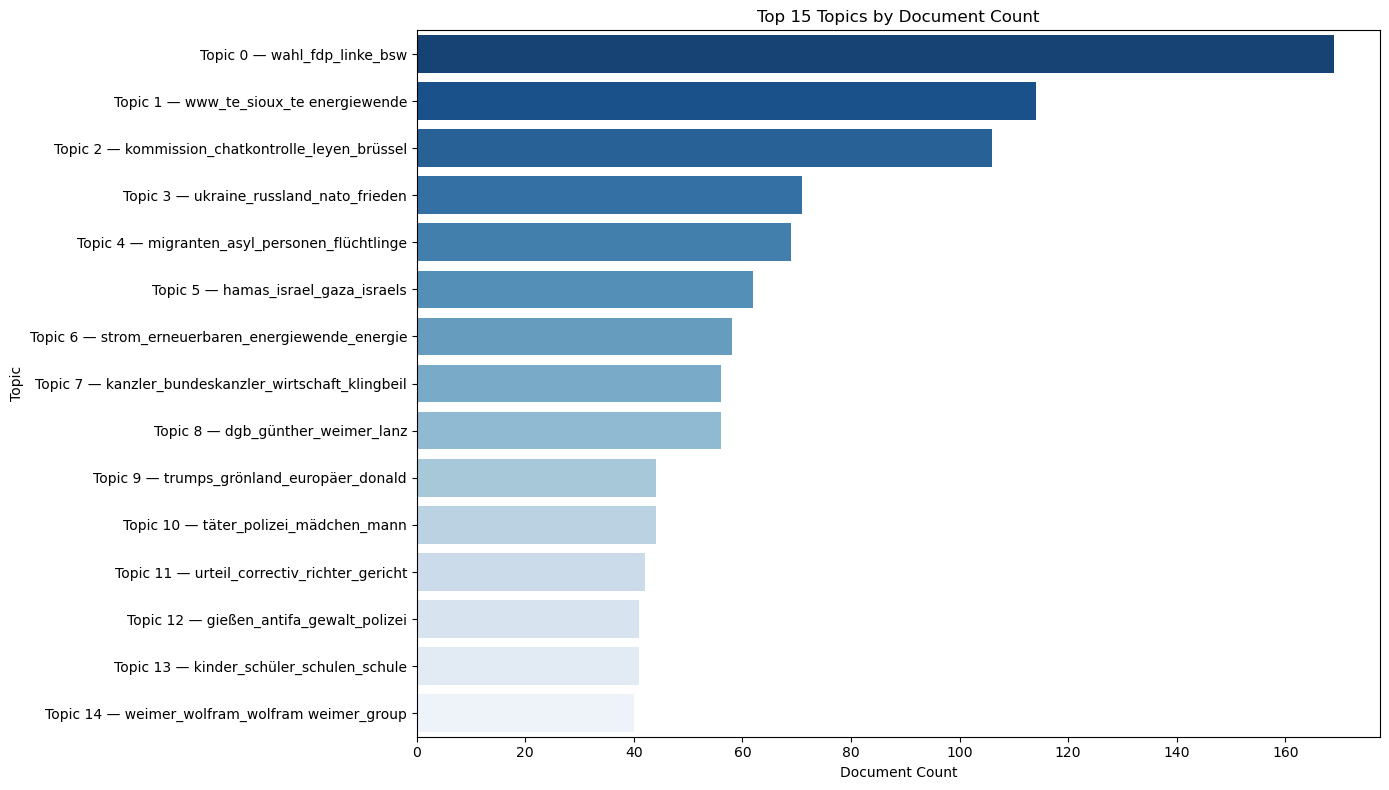

In [18]:
import seaborn as sns

# Ensure plotting libs exist in current kernel.
import matplotlib.pyplot as plt

# Re-run this cell after outlier reduction to visualize the final reduced model with unified topic numbering.
run_result = result_te_reduced if "result_te_reduced" in globals() else result_te
topic_info_run = run_result["topic_info"].copy()

if "DisplayTopic" not in topic_info_run.columns:
    topic_info_run["OriginalTopic"] = topic_info_run["Topic"]
    topic_info_run["TopicNameClean"] = topic_info_run["Name"].str.replace(r"^\d+_", "", regex=True)
    ranked_topics = (
        topic_info_run.loc[topic_info_run["Topic"] != -1, ["Topic", "Count"]]
        .sort_values(["Count", "Topic"], ascending=[False, True])
        .reset_index(drop=True)
    )
    ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
    display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))
    topic_info_run["DisplayTopic"] = topic_info_run["Topic"].map(display_topic_map).astype("Int64")
    topic_info_run["DisplayLabel"] = topic_info_run.apply(
        lambda row: "Outliers"
        if row["Topic"] == -1
        else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
        axis=1,
    )

top15_topics = (
    topic_info_run.loc[topic_info_run["Topic"] != -1]
    .nsmallest(15, "DisplayTopic")
    .sort_values("DisplayTopic")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=top15_topics,
    x="Count",
    y="DisplayLabel",
    order=top15_topics["DisplayLabel"].tolist(),
    palette="Blues_r",
    ax=ax,
)

ax.set_title("Top 15 Topics by Document Count (Reduced Model)")
ax.set_xlabel("Document Count")
ax.set_ylabel("Topic")
plt.tight_layout()
plt.show()


## OLD

In [86]:
# Prepare Tichy's Einblick dataframe for topic modeling
text_column = "Text" if "Text" in df.columns else "article_text"
df_clean = df[["title", "date", "url", text_column]].copy()
if text_column != "Text":
    df_clean = df_clean.rename(columns={text_column: "Text"})
df_clean["day"] = pd.to_datetime(df_clean["date"], errors="coerce")

df_clean["Text"] = (
    df_clean["Text"]
    .astype("string")
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

df_clean["title"] = (
    df_clean["title"]
    .astype("string")
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

df_clean = df_clean.dropna(subset=["day", "url", "Text"]).copy()

df_clean = df_clean[
    (df_clean["day"] >= "2025-08-01") & (df_clean["day"] <= "2026-01-31")
].copy()

print(f"Rows prepared for BERTopic: {len(df_clean):,}")
df_clean[["title", "Text", "day", "url"]].head()


Rows prepared for BERTopic: 2,946


title  \
0             Wegen Geschäften mit Russland: Trump droht Indien mit Sanktionen   
1                Wie robust ist der verfassungsrechtliche Schutz des Bargelds?   
2  Bis zur Selbstaufgabe: Wie Merz die SPD-Linken in der Koalition halten will   
3                                                  Bayern führt Wassercent ein   
4                                     Klima-Terroristen: Linke sind nicht nett   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [97]:
# BERTopic on full article text
result = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=25),
    id_col="url",
    source_name="Tichys_Einblick",
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 18:56:20,026 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/92 [00:00<?, ?it/s]

2026-03-08 18:56:33,713 - BERTopic - Embedding - Completed ✓
2026-03-08 18:56:33,715 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-08 18:56:39,816 - BERTopic - Dimensionality - Completed ✓
2026-03-08 18:56:39,817 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-08 18:56:39,852 - BERTopic - Cluster - Completed ✓
2026-03-08 18:56:39,855 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-08 18:56:42,100 - BERTopic - Representation - Completed ✓


In [98]:
import pandas as pd

pd.set_option("display.max_colwidth", None)

topic_info = result["topic_info"].copy()
topic_info["Representation_str"] = topic_info["Representation"].apply(
    lambda x: ", ".join(x) if isinstance(x, (list, tuple)) else str(x)
)

topic_info[["Topic", "Count", "Name", "Representation_str"]].head(50)

,Topic,Count,Name,Representation_str
0,-1,1113,-1_ukraine_linke_frauen_klingbeil,"ukraine, linke, frauen, klingbeil, china, bürgergeld, russland, weimer, polizei, stadt"
1,0,217,0_linke_fdp_bsw_wähler,"linke, fdp, bsw, wähler, wahlen, koalition, brandmauer, cdu csu, bundestag, wagenknecht"
2,1,157,1_brüssel_leyen_chatkontrolle_ursula,"brüssel, leyen, chatkontrolle, ursula, europäische, eu kommission, ursula leyen, digitalen, digitale, ukraine"
3,2,144,2_co2_energiewende_strom_industrie,"co2, energiewende, strom, industrie, energie, erneuerbaren, gas, wind, klimapolitik, china"
4,3,130,3_trumps_china_ukraine_donald,"trumps, china, ukraine, donald, russland, putin, donald trump, präsidenten, grönland, washington"
5,4,105,4_merkels_habeck_angela_angela merkel,"merkels, habeck, angela, angela merkel, klingbeil, ukraine, 2015, israel, lars, grosz"
6,5,98,5_www_sioux_te energiewende_energiewende wetterbericht,"www, sioux, te energiewende, energiewende wetterbericht, wetterbericht, sioux de, www sioux, energiewende, afghanen, gutschein"
7,6,76,6_kirche_papst_leo_kirk,"kirche, papst, leo, kirk, lanz, gott, christen, christlichen, gottes, jesus"
8,7,70,7_günther_dgb_weimer_lanz,"günther, dgb, weimer, lanz, journalisten, awo, sendung, wallasch, daniel, daniel günther"
9,8,66,8_porsche_china_hersteller_autos,"porsche, china, hersteller, autos, industrie, autobauer, markt, elektroautos, northvolt, autoindustrie"


### BERTopic quality metrics


In [99]:
# pip install gensim
import re
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel


def get_topic_words(topic_model, top_k=10, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=10):
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }


metrics = evaluate_bertopic(
    docs=result["docs"],
    topic_model=result["topic_model"],
    top_k=10,
)
metrics

{'coherence_npmi': -0.0033746669287296797,
 'topic_diversity': 0.8785714285714286,
 'num_topics': 28,
 'top_k': 10}

In [100]:
doc_info = result["doc_info"].copy()

# Compact topic overview: number of linked documents per topic (no long text columns).
group_cols = [c for c in ["Topic", "Name"] if c in doc_info.columns]
doc_info_overview = (
    doc_info.groupby(group_cols, dropna=False)
    .size()
    .reset_index(name="Doc_Count")
    .sort_values("Doc_Count", ascending=False)
    .reset_index(drop=True)
)

if "Probability" in doc_info.columns:
    avg_prob = (
        doc_info.groupby(group_cols, dropna=False)["Probability"]
        .mean()
        .reset_index(name="Avg_Probability")
    )
    doc_info_overview = doc_info_overview.merge(avg_prob, on=group_cols, how="left")
    doc_info_overview["Avg_Probability"] = doc_info_overview["Avg_Probability"].round(3)

if "Name" in doc_info_overview.columns:
    doc_info_overview["Name"] = doc_info_overview["Name"].astype("string").str.slice(0, 60)

doc_info_overview

,Topic,Name,Doc_Count,Avg_Probability
0,-1,-1_ukraine_linke_frauen_klingbeil,1113,0.000
1,0,0_linke_fdp_bsw_wähler,217,0.760
2,1,1_brüssel_leyen_chatkontrolle_ursula,157,0.656
3,2,2_co2_energiewende_strom_industrie,144,0.940
4,3,3_trumps_china_ukraine_donald,130,0.923
5,4,4_merkels_habeck_angela_angela merkel,105,0.754
6,5,5_www_sioux_te energiewende_energiewende wetterbericht,98,0.796
7,6,6_kirche_papst_leo_kirk,76,0.657
8,7,7_günther_dgb_weimer_lanz,70,0.808
9,8,8_porsche_china_hersteller_autos,66,0.913


In [91]:
tichys_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)

# Compact overview display (no full article text column).
display_cols = [c for c in ["day", "title", "Topic", "Name", "Probability"] if c in tichys_topics.columns]
tichys_topics[display_cols].head()


,day,title,Topic,Name,Probability
0,2025-08-01,Wegen Geschäften mit Russland: Trump droht Indien mit Sanktionen,26.0,26_putin_ukraine_selenskyj_russland,0.88798
1,2025-08-01,Wie robust ist der verfassungsrechtliche Schutz des Bargelds?,-1.0,-1_milliarden euro_bundesregierung_ukraine_demokratie,0.00000
2,2025-08-01,Bis zur Selbstaufgabe: Wie Merz die SPD-Linken in der Koalition halten will,0.0,0_partei_wahl_fdp_linke,1.00000
3,2025-08-01,Bayern führt Wassercent ein,-1.0,-1_milliarden euro_bundesregierung_ukraine_demokratie,0.00000
4,2025-08-01,Klima-Terroristen: Linke sind nicht nett,32.0,32_anschlag_bekennerschreiben_indymedia_berliner,1.00000


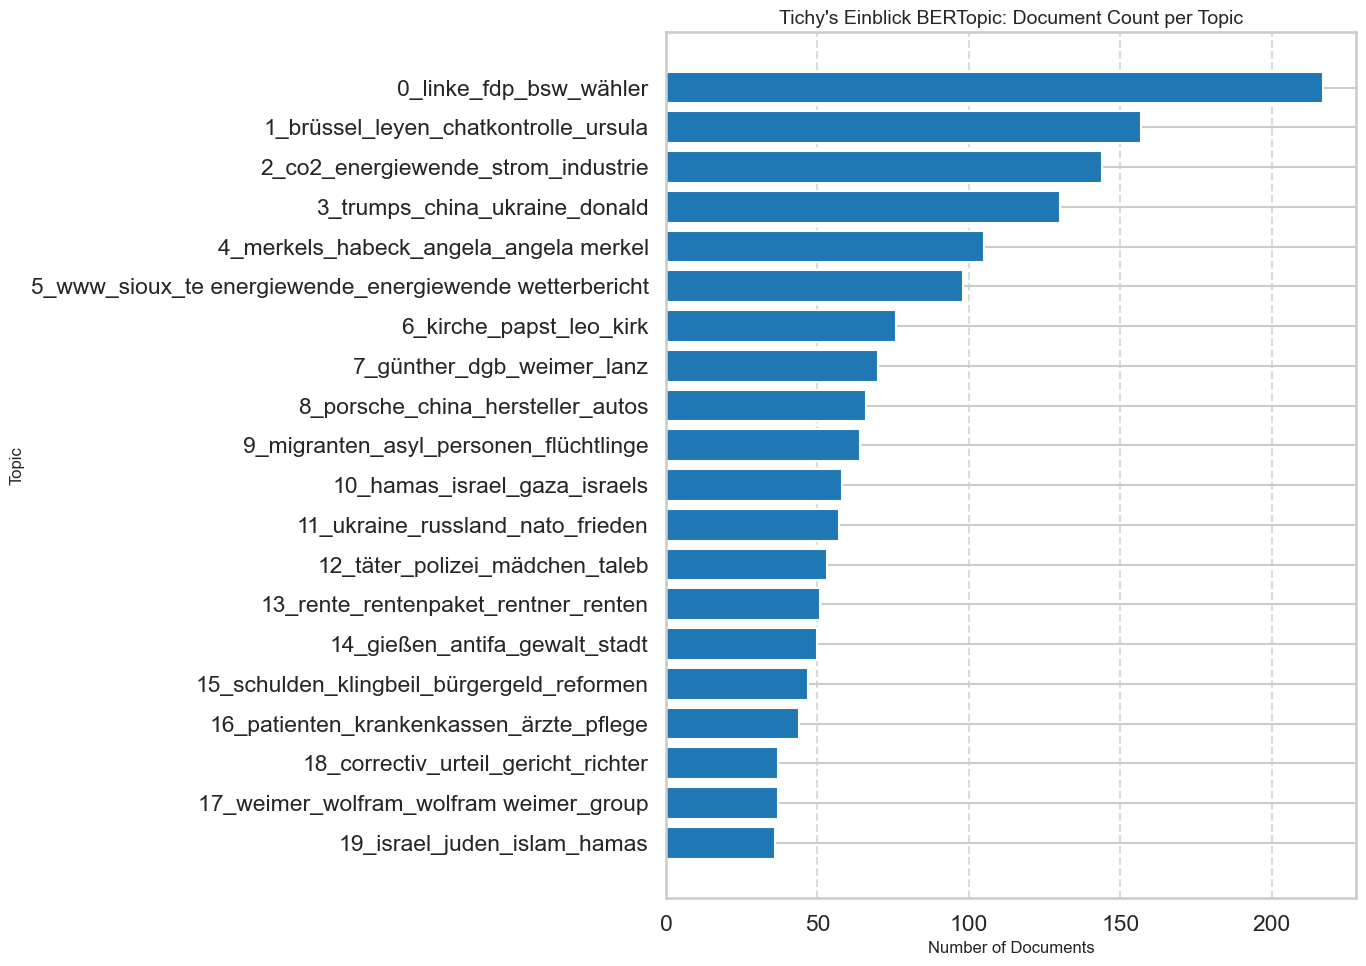

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 10))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info["Topic"] != -1].copy()
topic_counts = topic_counts.nlargest(20, "Count").sort_values("Count", ascending=True)

ax.barh(topic_counts["Name"], topic_counts["Count"], color="#1f77b4", edgecolor="white")

ax.set_xlabel("Number of Documents", fontsize=12)
ax.set_ylabel("Topic", fontsize=12)
ax.set_title("Tichy's Einblick BERTopic: Document Count per Topic", fontsize=14)
ax.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
# Prepare data for topics over time using the final reduced model if it already exists.
# Re-run this cell after outlier reduction to pick up `result_te_reduced`.
topic_time_result = result_te_reduced if "result_te_reduced" in globals() else result_te

topic_info_time = topic_time_result["topic_info"].copy()
prepared_docs_time = topic_time_result["prepared_documents"]
date_col = "Date" if "Date" in prepared_docs_time.columns else "day"
prepared_dates = pd.to_datetime(prepared_docs_time[date_col], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()

docs_for_time = [doc for doc, ok in zip(topic_time_result["docs"], valid_time_mask) if ok]
topics_for_time = [topic for topic, ok in zip(topic_time_result["topics"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = topic_time_result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    topics=topics_for_time,
    nr_bins=6,
)

topic_info_non_outliers = topic_info_time.loc[topic_info_time["Topic"] != -1].copy()
if "DisplayTopic" in topic_info_non_outliers.columns:
    top_10_topics = topic_info_non_outliers.nsmallest(10, "DisplayTopic")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["DisplayLabel"]))
else:
    top_10_topics = topic_info_non_outliers.nlargest(10, "Count")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["Name"]))

topics_over_time_filtered = topics_over_time[topics_over_time["Topic"].isin(top_10_topics)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered["Topic"] == topic]
    label = label_map.get(topic, f"Topic {topic}")
    ax.plot(
        topic_data["Timestamp"],
        topic_data["Frequency"],
        marker="o",
        linewidth=2.5,
        markersize=8,
        color=palette[i],
        label=label,
    )

ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Number of Documents", fontsize=14)
ax.set_title("Tichy's Einblick: Top 10 Topics Over Time (Aug 2025 - Jan 2026)", fontsize=16, fontweight="bold")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
